# Flickr30k — Dataset Download & Visualisation

Downloads the **Flickr30k** benchmark from `nlphuji/flickr30k` on Hugging Face
and produces a series of visualisations:

1. Sample images with their 5 reference captions  
2. Caption length distribution  
3. Top-50 most common words (word cloud + bar chart)  
4. Image aspect-ratio / resolution distribution  
5. Number of images per split

In [1]:
# ── 0. Auth & optional deps ──────────────────────────────────────────────────
import os, getpass

if not os.environ.get('HF_TOKEN'):
    os.environ['HF_TOKEN'] = getpass.getpass('Hugging Face token (read scope): ')

# wordcloud is not in requirements.txt — install if missing
try:
    import wordcloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'wordcloud'])

In [2]:
# ── 1. Download ──────────────────────────────────────────────────────────────
# datasets >= 4.0 no longer runs custom loading scripts.
# We load via the HF auto-generated parquet export (refs/convert/parquet).
# Actual schema: image{bytes,path}, caption[str], sentids[str], split, img_id, filename
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_download
import io
from PIL import Image as PILImage

token   = os.environ.get('HF_TOKEN')
repo_id = 'nlphuji/flickr30k'

api      = HfApi(token=token)
pq_names = sorted(
    f for f in api.list_repo_files(
        repo_id, repo_type='dataset', revision='refs/convert/parquet'
    )
    if f.endswith('.parquet')
)
print(f'Found {len(pq_names)} parquet shard(s)')

local_files = [
    hf_hub_download(
        repo_id=repo_id, filename=f,
        repo_type='dataset', revision='refs/convert/parquet', token=token,
    )
    for f in pq_names
]

# No features= so datasets infers the schema — avoids CastError from extra columns
ds = load_dataset('parquet', data_files={'test': local_files})
print(ds)

split = ds['test']
print(f'\nRows    : {len(split):,}')
print('Columns :', split.column_names)

def get_image(row) -> PILImage.Image:
    """Decode the image column (dict with 'bytes') to a PIL Image."""
    img = row['image']
    if isinstance(img, PILImage.Image):
        return img
    return PILImage.open(io.BytesIO(img['bytes'])).convert('RGB')

/Users/siddharthraj/Documents/my-projects/region-grounded/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 9 parquet shard(s)
DatasetDict({
    test: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})

Rows    : 31,014
Columns : ['image', 'caption', 'sentids', 'split', 'img_id', 'filename']


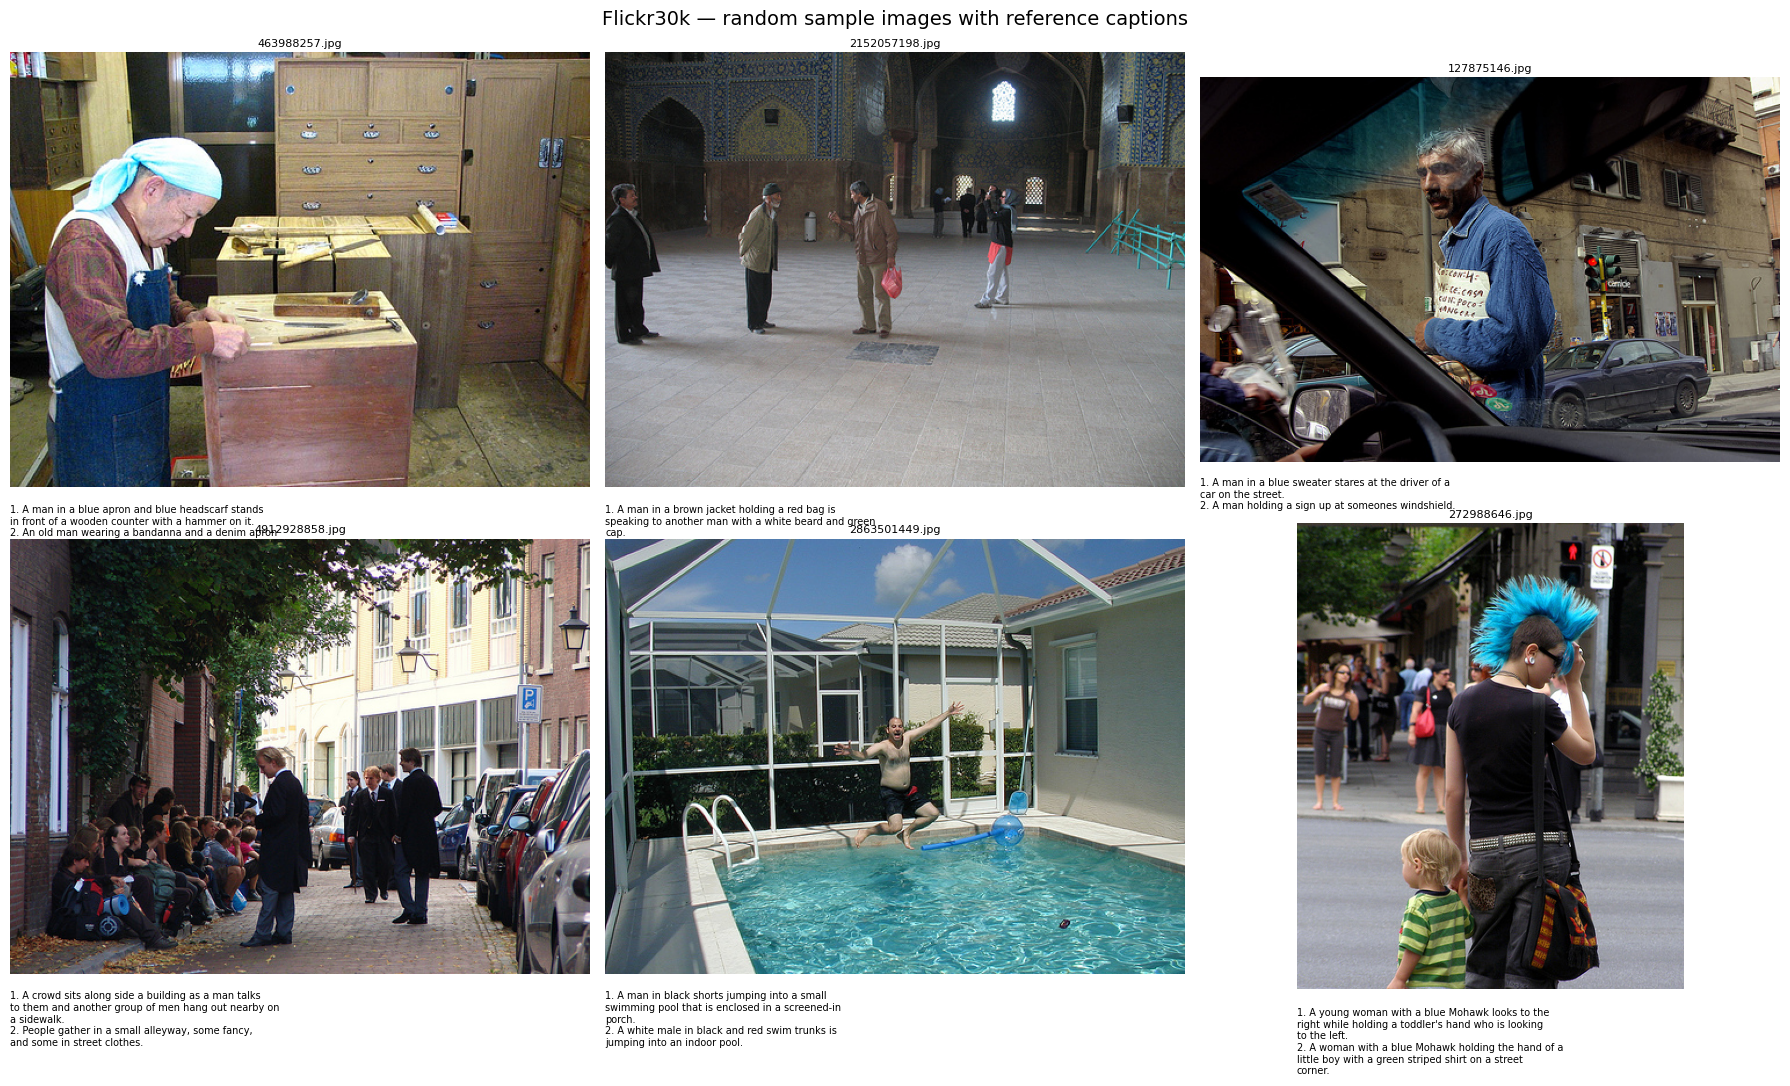

In [3]:
# ── 2. Sample images with captions ──────────────────────────────────────────
import random
import textwrap
import matplotlib.pyplot as plt

random.seed(42)
indices = random.sample(range(len(split)), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Flickr30k — random sample images with reference captions', fontsize=14)

for ax, idx in zip(axes.flat, indices):
    row = split[idx]
    img = get_image(row)
    captions = row['caption']
    filename = row.get('filename', f'idx-{idx}')

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(filename, fontsize=8, pad=4)

    label = '\n'.join(
        textwrap.fill(f'{i+1}. {c}', 52)
        for i, c in enumerate(captions[:2])
    )
    ax.text(0, -0.04, label, transform=ax.transAxes, va='top', fontsize=7)

plt.tight_layout()
plt.show()

In [4]:
# ── 3. Caption-length distribution ──────────────────────────────────────────
import numpy as np

lengths = np.array([
    len(cap.split())
    for row in split
    for cap in row['caption']
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(lengths.mean(),     color='tomato', linewidth=1.5,
           label=f'mean = {lengths.mean():.1f}')
ax.axvline(np.median(lengths), color='gold',   linewidth=1.5, linestyle='--',
           label=f'median = {np.median(lengths):.0f}')
ax.set_xlabel('Caption length (words)')
ax.set_ylabel('Count')
ax.set_title(f'Flickr30k caption length distribution  (n = {len(lengths):,} captions)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'min={lengths.min()}  max={lengths.max()}  '
      f'mean={lengths.mean():.1f}  std={lengths.std():.1f}')

KeyboardInterrupt: 

In [ ]:
# ── 4. Word-frequency: bar chart + word cloud ────────────────────────────────
import re
from collections import Counter
from wordcloud import WordCloud

STOPWORDS = {
    'a','an','the','is','are','in','on','of','and','with','to','at','by',
    'for','from','that','this','its','their','his','her','he','she','it',
    'they','as','into','over','through','while','who','two','three','one',
    'four','five','wearing','man','woman','men','women','people','person',
    'boy','girl',
}

tokens: list[str] = []
for row in split:
    for cap in row['caption']:
        tokens.extend(
            w for w in re.findall(r'[a-z]+', cap.lower())
            if w not in STOPWORDS and len(w) > 2
        )

counter = Counter(tokens)
top50 = counter.most_common(50)
words, counts = zip(*top50)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(words[::-1], counts[::-1], color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top-50 words (stopwords removed)')
axes[0].tick_params(axis='y', labelsize=8)

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Blues', max_words=200).generate_from_frequencies(counter)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word cloud')

plt.tight_layout()
plt.show()

In [ ]:
# ── 5. Image resolution & aspect-ratio ──────────────────────────────────────
widths, heights = [], []
for row in split:
    w, h = get_image(row).size
    widths.append(w)
    heights.append(h)

widths  = np.array(widths)
heights = np.array(heights)
ratios  = widths / heights

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(widths,  bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Width (px)');  axes[0].set_title('Image widths')

axes[1].hist(heights, bins=40, color='cornflowerblue', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Height (px)'); axes[1].set_title('Image heights')

axes[2].hist(ratios,  bins=40, color='mediumpurple',   edgecolor='white', linewidth=0.4)
axes[2].axvline(1.0, color='tomato', linewidth=1.2, linestyle='--', label='square (1:1)')
axes[2].set_xlabel('Aspect ratio (w/h)'); axes[2].set_title('Aspect ratios')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_ylabel('Count')

plt.suptitle('Flickr30k image resolution statistics', y=1.02)
plt.tight_layout()
plt.show()

print(f'Width  — min={widths.min()}  max={widths.max()}  mean={widths.mean():.0f}')
print(f'Height — min={heights.min()}  max={heights.max()}  mean={heights.mean():.0f}')
print(f'Ratio  — min={ratios.min():.2f}  max={ratios.max():.2f}  mean={ratios.mean():.2f}')

In [ ]:
# ── 6. Split breakdown (train / val / test) ──────────────────────────────────
# nlphuji/flickr30k includes a 'split' column marking each image's official partition.
if 'split' in split.column_names:
    split_counts = Counter(row['split'] for row in split)
    labels, values = zip(*sorted(split_counts.items()))
    colors = {'train': 'steelblue', 'val': 'coral', 'test': 'mediumseagreen'}
    bar_colors = [colors.get(l, 'grey') for l in labels]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, values, color=bar_colors)
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_ylabel('Images')
    ax.set_title('Flickr30k — images per split')
    plt.tight_layout()
    plt.show()
else:
    print('No "split" column — dataset served as a single partition.')
    print(f'Total images: {len(split):,}')

In [ ]:
# ── 7. Summary ───────────────────────────────────────────────────────────────
print('=== Flickr30k Dataset Summary ===')
print(f'  Total images          : {len(split):,}')
print(f'  Captions per image    : {len(split[0]["caption"])}')
print(f'  Total captions        : {len(split) * len(split[0]["caption"]):,}')
print(f'  Avg caption length    : {lengths.mean():.1f} words')
print(f'  Median caption length : {int(np.median(lengths))} words')
print(f'  Unique vocabulary     : {len(counter):,} tokens')